## Row scan (AscendC versus CCE)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from os.path import join

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 6.5
plt.rcParams['lines.linewidth'] = 1.75
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.75
_MARKERS = ["o", "^", "s", "X"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}


In [2]:
# Select plot parameters

# dtype = "int8"
dtype = "fp16"
tiles = [128, 512]

In [3]:
def add_stats_siso(df, nbytes_out_dtype: int):
    # Input number of bytes per element
    df["in_bytes_per_elem"] = df["dtype"].map({"fp32": 4, "fp16": 2, "int8": 1})

    df["mem_bytes"] = df["size"] * (df["in_bytes_per_elem"] + nbytes_out_dtype)
    
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

In [4]:
df_copy_fp32 = pd.read_csv(join('..', '..', "bench_results_copy_fp32.csv"))
add_stats_siso(df_copy_fp32, 4)
df_copy_fp32["S"] = "copy (fp32)"
df_copy_fp32["tflops"] = (df_copy_fp32["size"] / 1e12) / (df_copy_fp32["time_us"] / 1e6)

df_copy_fp16 = pd.read_csv(join('..', '..', "bench_results_copy_fp16.csv"))
add_stats_siso(df_copy_fp16, 2)
df_copy_fp16["S"] = "copy (fp16)"
df_copy_fp16["tflops"] = (df_copy_fp16["size"] / 1e12) / (df_copy_fp16["time_us"] / 1e6)

df_cast_fp16 = pd.read_csv(join('..', '..', "bench_results_cast_fp16.csv"))
add_stats_siso(df_cast_fp16, 4)
df_cast_fp16["S"] = "cast (fp16 -> fp32)"
df_cast_fp16["tflops"] = (df_cast_fp16["size"] / 1e12) / (df_cast_fp16["time_us"] / 1e6)
df_copy = pd.concat([df_cast_fp16])

df_tiled = pd.DataFrame()
for tile in tiles:
    df_tmp = pd.concat(map(pd.read_csv, glob(join('..', '..', f"bench_results_row_scan*{tile}_{dtype}.csv"))))
    df_tmp["S"] = df_tmp["operator"]
    df_tmp["tflops"] = (df_tmp["size"] * tile) / (df_tmp["time_us"] * 1e6)
    df_tiled = pd.concat([df_tiled, df_tmp])

add_stats_siso(df_tiled, 4)

df = pd.concat([df_copy, df_tiled])

## Paper plots

/tmp/ipykernel_3082486/3550651167.py:1: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='gelemps', **_SNS_PARAMS)


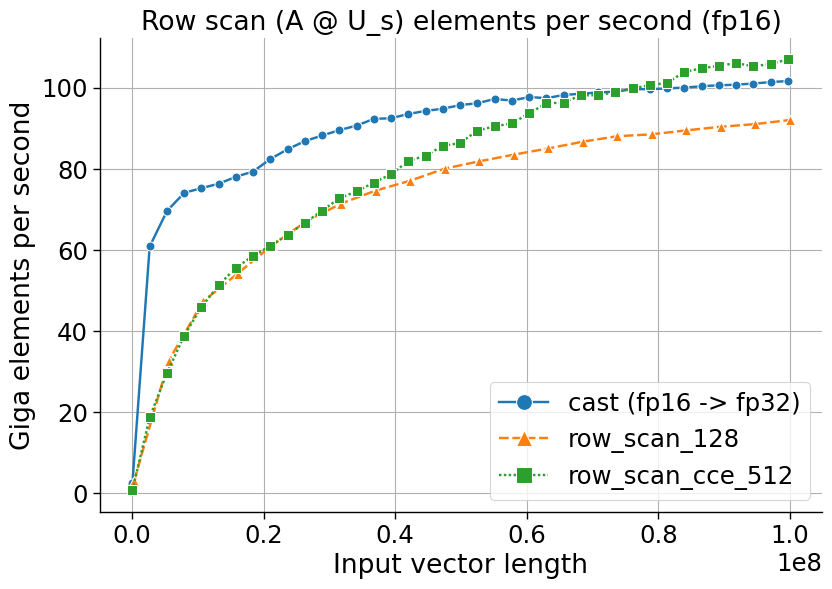

<Figure size 870x627 with 0 Axes>

In [5]:
ax = sns.lineplot(data=df, x='size', y='gelemps', **_SNS_PARAMS)

ax.set_title(f"Row scan (A @ U_s) elements per second ({dtype})")
ax.set_xlabel("Input vector length")
ax.set_ylabel("Giga elements per second")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()
plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"mcscan_gelemsps_{dtype}.png")
plt.show()
plt.clf()

/tmp/ipykernel_3082486/2880780571.py:1: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', **_SNS_PARAMS)


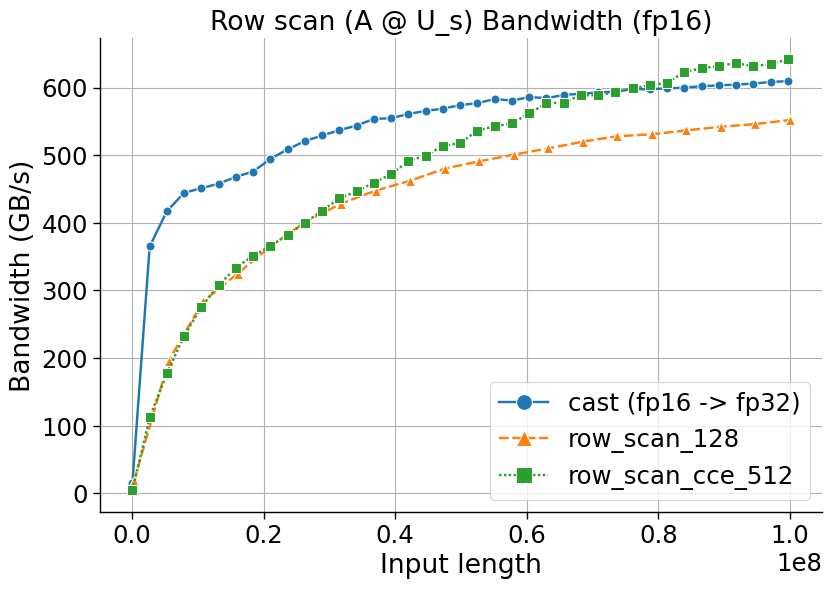

<Figure size 870x627 with 0 Axes>

In [6]:
ax = sns.lineplot(data=df, x='size', y='bw_gbps', **_SNS_PARAMS)

ax.set_title(f"Row scan (A @ U_s) Bandwidth ({dtype})")
ax.set_xlabel("Input length")
ax.set_ylabel("Bandwidth (GB/s)")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"mcscan_bw_{dtype}.png")
plt.show()
plt.clf()


/tmp/ipykernel_3082486/1746237332.py:1: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='tflops', **_SNS_PARAMS)


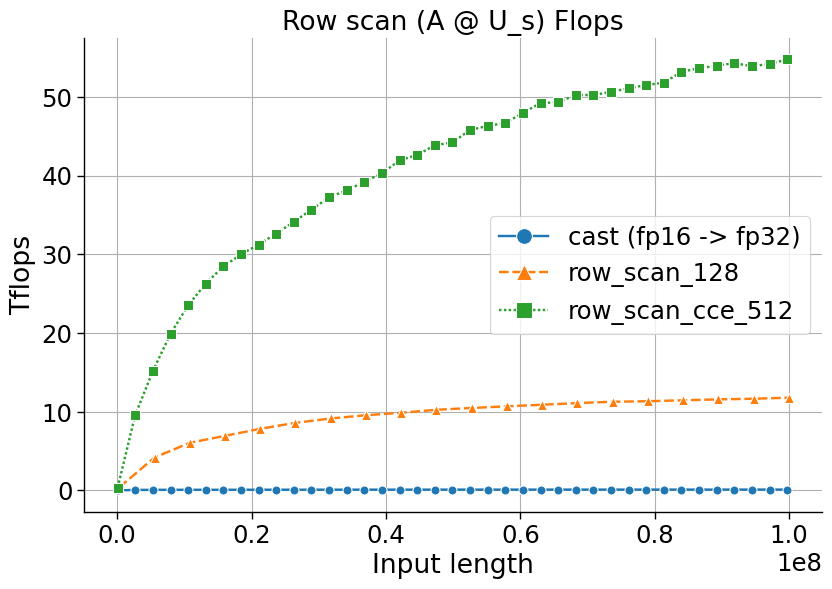

<Figure size 870x627 with 0 Axes>

In [8]:
ax = sns.lineplot(data=df, x='size', y='tflops', **_SNS_PARAMS)

ax.set_title(f"Row scan (A @ U_s) Flops")
ax.set_xlabel("Input length")
ax.set_ylabel("Tflops")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"mcscan_bw_{dtype}.png")
plt.show()
plt.clf()